In [1]:
from neuromodes.TEMP_utils import plot_mesh_data
from nibabel.affines import apply_affine
from nibabel.loadsave import load
import numpy as np
from neuromodes import EigenSolver
from neuromodes.mesh import make_vol_mesh, tetmesh_to_nifti, nifti_to_tetmesh
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from nilearn.plotting import plot_stat_map

neuromodes = 'C:/Users/ipop0003/neuromodes'

In [2]:
# Get NIFTI and make volumetric mesh
niftipath = f'{neuromodes}/TEMP_investigations/hcp_hippo-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti)

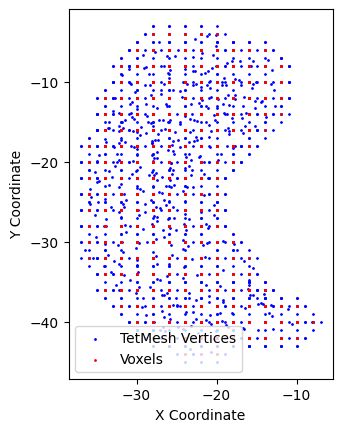

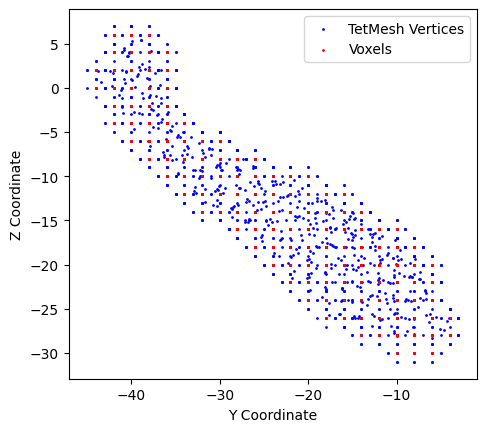

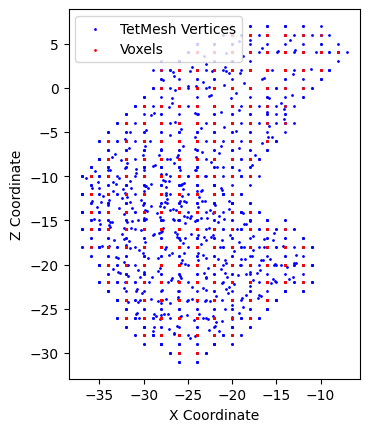

In [3]:
# plot x-y coords of surface and voxels in world space
xyz = np.column_stack(np.where(nifti.get_fdata() > 0))      # (i,j,k) = (z,y,x)
xyz = apply_affine(nifti.affine, xyz)       # world space

# Plot vol & mesh
plt.scatter(vol.v[:, 0], vol.v[:, 1], s=1, color='blue', label='TetMesh Vertices')
plt.scatter(xyz[:, 0], xyz[:, 1], s=1, color='red', label='Voxels')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

# Same plot but y-z coords
plt.scatter(vol.v[:, 1], vol.v[:, 2], s=1, color='blue', label='TetMesh Vertices')
plt.scatter(xyz[:, 1], xyz[:, 2], s=1, color='red', label='Voxels')
plt.xlabel('Y Coordinate')
plt.ylabel('Z Coordinate')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

# Same plot but x-z coords
plt.scatter(vol.v[:, 0], vol.v[:, 2], s=1, color='blue', label='TetMesh Vertices')
plt.scatter(xyz[:, 0], xyz[:, 2], s=1, color='red', label='Voxels')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()


In [4]:
# Solve eigenmodes on volumetric mesh
solver = EigenSolver(vol).solve(10)

# Visualise tetmesh
plot_mesh_data(vol, solver.emodes[:, 7])

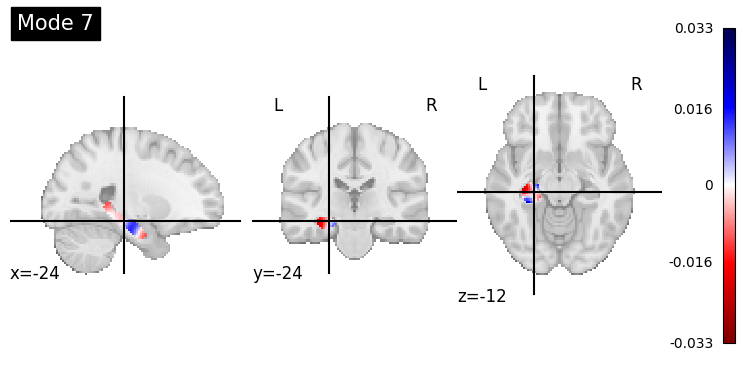

In [5]:
# Try transformation function
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)

plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r', symmetric_cbar=True, title='Mode 7')

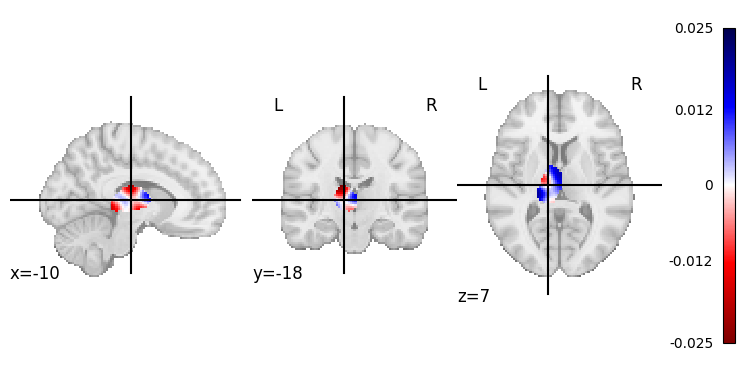

In [6]:
# Try thalamus and striatum
niftipath = f'{neuromodes}/TEMP_investigations/hcp_tha-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti)
solver = EigenSolver(vol).solve(10)
plot_mesh_data(vol, solver.emodes[:, 7])
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)
plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

Components discarded: 1.
    - 6 vertices.


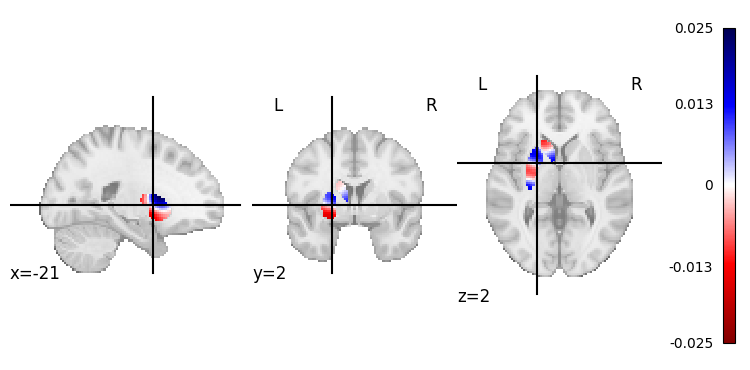

In [11]:
# Try striatum
niftipath = f'{neuromodes}/TEMP_investigations/hcp_striatum-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti, discard_components=True)
solver = EigenSolver(vol).solve(10)
plot_mesh_data(vol, solver.emodes[:, -1])
mode_nifti = tetmesh_to_nifti(solver.emodes[:, -1], solver.geometry, nifti)
plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

### nifti_to_tetmesh interp

In [9]:
plot_mesh_data(vol, solver.emodes[:, -1], cmap_center=0)
mode_nifti = tetmesh_to_nifti(solver.emodes[:, -1], solver.geometry, nifti)

mode_tetmesh = nifti_to_tetmesh(mode_nifti, vol)
plot_mesh_data(vol, mode_tetmesh, cmap_center=0)

# Print correlation between original and interpolated values at vertex locations
corr = np.corrcoef(solver.emodes[:, -1], mode_tetmesh)[0, 1]
print(f'Correlation between original and interpolated values at vertices: {corr:.4f}')

Correlation between original and interpolated values at vertices: 0.8718
